### Step 1) Import Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

2026-07-30 08:00:05.022129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785398405.213022    1768 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785398405.272282    1768 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785398405.703760    1768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785398405.703819    1768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785398405.703821    1768 computation_placer.cc:177] computation placer alr

In [4]:
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Step 2) Set Parameters

In [5]:
train_path = "dataset/train"

IMG_SIZE = (150, 150)
BATCH_SIZE = 16
SEED = 42


### Step 3) Load Dataset

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.


I0000 00:00:1785398439.349195    1768 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2248 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


### Step 4) Class Name

In [10]:
class_names = train_ds.class_names

print("Classes: ", class_names)

Classes:  ['cats', 'dogs']


In [11]:
for images, labels in train_ds:
    print(images.shape)
    print(labels.shape)
    break

(16, 150, 150, 3)
(16,)


In [12]:
type(train_ds)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

### Step 5) Display Sample Images

2026-07-30 08:01:12.412779: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


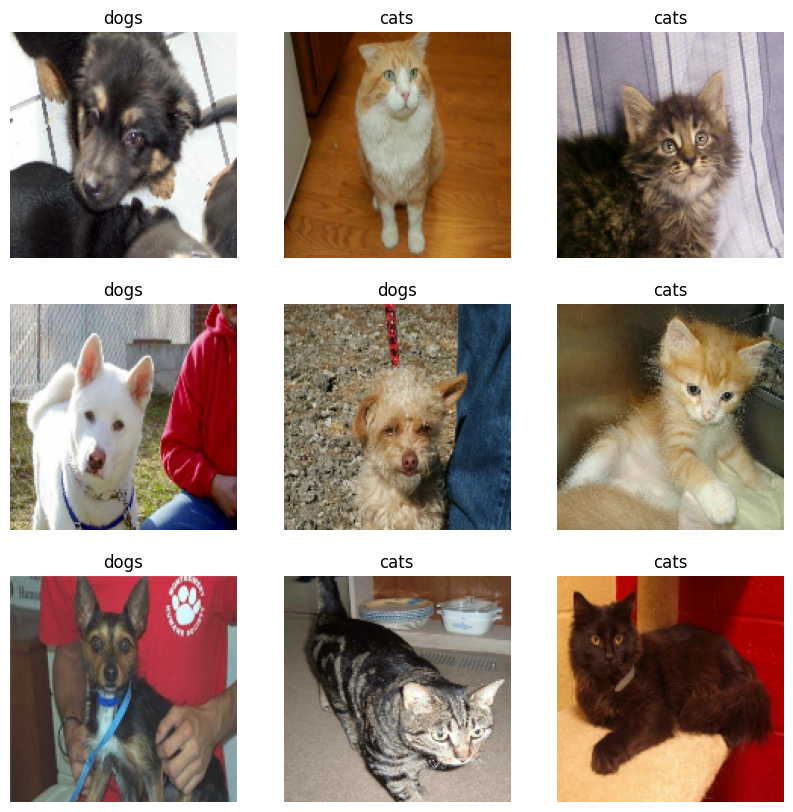

In [13]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

### Step 6) Data Preprocessing

In [14]:
# Normalize Image

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

### Step 7) Improve Performance

In [15]:
# AUTOTUNE = tf.data.AUTOTUNE

# train_ds = train_ds.shuffle(200).prefetch(AUTOTUNE)
# val_ds = val_ds.cache().prefetch(AUTOTUNE)

### Step 8) Data Augmentation

In [16]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

### Step 9) Define CNN Model Architecture

In [37]:
model = models.Sequential([

    layers.Input(shape=(150,150,3)),
    
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

### Step 10) Compile Model

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Step 11) Model Summary

In [39]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.5649 - loss: 0.6743 - val_accuracy: 0.6093 - val_loss: 66.1778
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 47ms/step - accuracy: 0.6864 - loss: 0.5887 - val_accuracy: 0.6635 - val_loss: 56.8923
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - accuracy: 0.7165 - loss: 0.5491 - val_accuracy: 0.6930 - val_loss: 62.6463
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 49s 46ms/step - accuracy: 0.7437 - loss: 0.5181 - val_accuracy: 0.6158 - val_loss: 96.7656
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.7539 - loss: 0.4938 - val_accuracy: 0.6348 - val_loss: 99.7088
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 43ms/step - accuracy: 0.7785 - loss: 0.4694 - val_accuracy: 0.7240 - val_loss: 51.6108
Epoch 7/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.7877 - loss: 0.4545 - val_accuracy: 0.7080 - val_loss: 57.7137
Epoch 8/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 48ms/step - accuracy: 0

### Step 13) Plot Accuracy

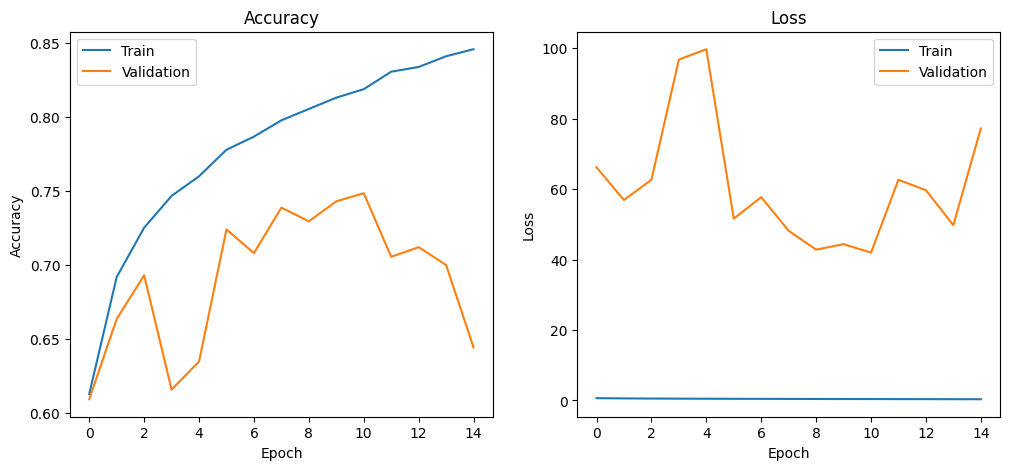

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Step 14) Evaluate Model 

In [42]:
loss, accuracy = model.evaluate(train_ds)

print(f"Train Loss: {loss:.4f}")

print(f"Train Accuracy: {accuracy:.4f}")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8501 - loss: 0.3389
Train Loss: 0.3411
Train Accuracy: 0.8471


In [43]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6477 - loss: 75.1514
Validation Loss: 77.2154
Validation Accuracy: 0.6442


### Step 15) Predictions

In [44]:
predictions = model.predict(val_ds)

predictions = (predictions > 0.5).astype(int)

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


### Step 16) Confusion Matrix

2026-07-30 10:53:27.236334: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


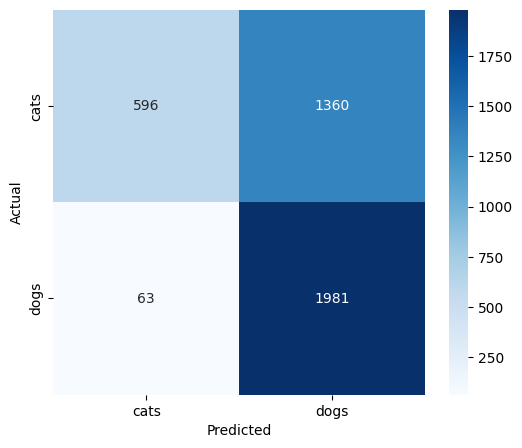

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Step 17) Classification Report

In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        cats       0.86      0.41      0.55      1956
        dogs       0.62      0.94      0.75      2044

    accuracy                           0.68      4000
   macro avg       0.74      0.67      0.65      4000
weighted avg       0.74      0.68      0.65      4000



### Step 18) Test on a single Image

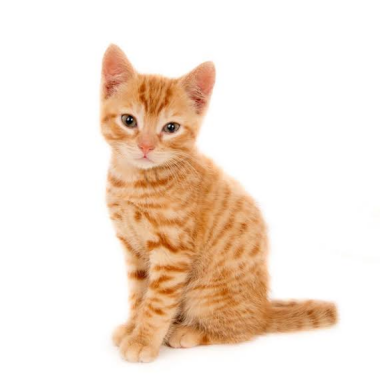

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Prediction: Cat
Probability: 0.17686042


In [34]:
img_path = "test_image4.jpg"

img = plt.imread(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(150,150)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    print("Prediction: Dog")
else:
    print("Prediction: Cat")

print("Probability:", prediction)

### Step 19) Save Model

In [ ]:
model.save("cats_vs_dogs_cnn.keras")

In [36]:
import os

cat_count = len(os.listdir("dataset/train/cats"))
dog_count = len(os.listdir("dataset/train/dogs"))

print("Cats:", cat_count)
print("Dogs:", dog_count)

Cats: 10000
Dogs: 10000
